# Statistical Analysis of Turkish Makam Music Datasets

Statistical analysis provides the foundation for understanding the structure, quality, and characteristics of symbolic music datasets before applying more advanced computational methods. By examining descriptive statistics, annotation distributions, feature variability, and corpus organization, researchers can gain valuable insight into the properties of the data and select appropriate analytical techniques for subsequent studies.

This notebook presents a reproducible statistical analysis workflow for three complementary Turkish makam music datasets. Although all three datasets originate from the same musical tradition, they represent different levels of musical abstraction and therefore require different statistical analysis strategies. Rather than applying identical analyses to every dataset, each corpus is examined using methods that best reflect its underlying data structure and intended research applications.

The analyses presented in this notebook establish the statistical foundation for the visualization, dimensionality reduction, clustering, and similarity analyses introduced in the following chapters of this tutorial.

| Dataset                                                | Statistical Analysis Sections                                                                                                                               |
| ------------------------------------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **SymbTr v3.0**                                        | Dataset Overview, Missing Value Analysis, Feature Variability Analysis, Correlation Analysis                                                                |
| **Turkish Makam Symbolic Phrase Segmentation Dataset** | Corpus Overview, Expert-Level Annotation Statistics, Note Event Statistics                                                                                  |
| **Turkish Makam Melodic Phrase Dataset**               | Corpus Overview, Expert-Level Annotation Statistics, Phrase Length Statistics, Symbolic Pitch Distribution (Koma53), Duration Statistics, Offset Statistics |


## Part I —Statistical Analysis of Turkish Makam Symbolic Phrase Segmentation Dataset

The Turkish Makam Symbolic Phrase Segmentation Dataset provides expert-generated phrase boundary annotations for symbolic Turkish makam music. Unlike numerical feature datasets, this corpus focuses on the structural segmentation of complete musical scores into meaningful symbolic phrases.

The dataset supports phrase segmentation research, corpus-based computational musicology, symbolic music processing, and machine learning applications that require phrase-level annotations. The following statistical analyses examine the structural organization of the corpus, expert annotation coverage, and annotation characteristics to establish a reproducible foundation for subsequent computational analyses.

### Why Perform Statistical Analysis on the Turkish Makam Symbolic Phrase Segmentation Dataset?

Statistical analysis of the Turkish Makam Symbolic Phrase Segmentation Dataset is essential for understanding the structural characteristics of the annotation corpus before conducting phrase-level computational analyses. Unlike numerical feature datasets, this corpus consists of expert-generated phrase boundary annotations that describe the internal organization of symbolic Turkish makam music.

By examining corpus statistics, annotation distributions, expert contributions, and structural characteristics, researchers can evaluate the completeness, consistency, and representativeness of the dataset. These analyses also provide valuable insights into the annotation process and establish a reproducible analytical framework for symbolic phrase segmentation research.

The findings presented in this section provide the foundation for subsequent phrase visualization, corpus comparison, and computational musicology applications discussed throughout this tutorial.

### Corpus Overview

The following table summarizes the basic structural characteristics of the Turkish Makam Symbolic Phrase Segmentation Dataset, including the number of expert annotators, annotation files, and corpus organization. This overview provides an initial understanding of the annotation corpus before more detailed statistical analyses are performed.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# =============================================================================
# Dataset paths
# =============================================================================

project_root = Path.cwd().parent

annotation_dir = (
    project_root
    / "data"
    / "raw"
    / "symbolic_phrase"
    / "extracted"
    / "MTG-otmm_symbolic_phrase_dataset-2f6cca9"
    / "annotations"
)

print(annotation_dir)

C:\Users\tualtan\Projects\SymbTr-Analysis-Book\webbook\data\raw\symbolic_phrase\extracted\MTG-otmm_symbolic_phrase_dataset-2f6cca9\annotations


In [12]:
expert_summary = []

for expert in expert_dirs:

    files = list(expert.rglob("*.txt"))

    expert_summary.append({
        "Expert": expert.name,
        "Annotation Files": len(files)
    })

expert_summary = pd.DataFrame(expert_summary)

display(expert_summary)

,Expert,Annotation Files
0,expert1,488
1,expert2,199
2,expert3,201


### Interpretation of the Expert-Level Annotation Statistics

The expert-level annotation statistics show that the Turkish Makam Symbolic Phrase Segmentation Dataset is composed of annotations contributed by three expert musicians. While **expert1** provides annotations for the complete collection of musical scores, **expert2** and **expert3** contribute annotations for complementary subsets of the corpus. This asymmetric distribution reflects the original annotation strategy of the dataset rather than missing or incomplete data.

Understanding the annotation coverage of each expert is important when selecting subsets of the corpus for phrase segmentation studies, expert agreement analyses, and supervised machine learning applications. Researchers should therefore consider the available expert annotations when designing reproducible computational experiments based on this dataset.

### Note Event Statistics

Each annotation file contains a sequence of symbolic note events describing the musical content associated with a segmented composition. The following statistics summarize the distribution of note events across the annotation corpus and provide an overview of the structural complexity of the annotated musical scores.

### Why Analyze Note Event Statistics?

The number of symbolic note events is one of the primary structural characteristics of symbolic music datasets. Examining the distribution of note events helps researchers understand the complexity of annotated musical scores, evaluate corpus diversity, and identify variations in musical length and density across the collection.

These statistics provide an important reference for symbolic music analysis, computational musicology, and machine learning applications operating on note-level symbolic representations.

In [13]:
# =============================================================================
# Note event statistics
# =============================================================================

note_event_counts = []
failed_files = []

expert1_dir = annotation_dir / "expert1"

for txt_file in expert1_dir.rglob("*.txt"):

    try:
        with open(txt_file, "r", encoding="utf-8", errors="ignore") as f:
            lines = [
                line.strip()
                for line in f.readlines()[1:]   # skip header
                if line.strip()
            ]

        note_event_counts.append(len(lines))

    except Exception as e:
        failed_files.append((txt_file.name, str(e)))

print(f"Successfully read : {len(note_event_counts)}")
print(f"Failed to read    : {len(failed_files)}")

if failed_files:
    failed_df = pd.DataFrame(
        failed_files,
        columns=["File", "Error"]
    )
    display(failed_df)

note_event_statistics = pd.Series(
    note_event_counts,
    name="Note Events per Musical Score"
)

display(
    note_event_statistics
    .describe()
    .round(2)
    .to_frame()
)

Successfully read : 488
Failed to read    : 0


,Note Events per Musical Score
count,488.00
mean,551.50
std,378.59
min,52.00
25%,398.00
50%,492.00
75%,612.00
max,6636.00


### Distribution of Note Events

The following histogram illustrates the distribution of symbolic note events across annotated musical scores. Visualizing the distribution provides additional insight into the structural diversity of the corpus and complements the descriptive statistics presented above.

In [15]:
# =============================================================================
# Imports
# =============================================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

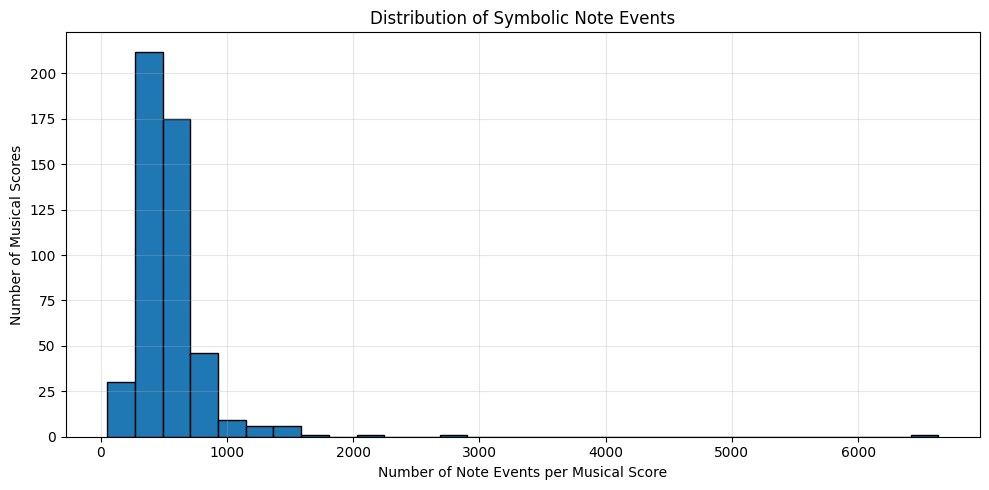

In [16]:
# =============================================================================
# Distribution of note events
# =============================================================================

plt.figure(figsize=(10,5))

plt.hist(
    note_event_counts,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Symbolic Note Events")

plt.xlabel("Number of Note Events per Musical Score")

plt.ylabel("Number of Musical Scores")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation of the Note Event Statistics

The note event statistics reveal substantial variation in the number of symbolic note events contained within annotated musical scores. While many compositions exhibit a moderate number of note events, others contain considerably denser symbolic representations, indicating differences in musical complexity and structural organization.

This variability reflects the diversity of Turkish makam music represented in the corpus and demonstrates that the dataset encompasses musical scores with a wide range of structural characteristics. The complete analysis of all annotated musical scores provides a reliable statistical foundation for phrase segmentation research, symbolic music analysis, computational musicology, and machine learning applications.

### Key Findings

The statistical analyses demonstrate that the Turkish Makam Symbolic Phrase Segmentation Dataset provides a comprehensive and well-structured expert-annotated corpus for phrase-level symbolic music research. The analyses confirmed the completeness of the annotation corpus, revealed the distribution of expert contributions, and characterized the structural variability of symbolic note events across annotated musical scores.

Together, these findings establish a reliable foundation for phrase segmentation, corpus-based computational musicology, symbolic music processing, expert agreement studies, and machine learning applications based on expert-generated symbolic annotations.

## Part II — Statistical Analysis of the Turkish Makam Melodic Phrase Dataset

The Turkish Makam Melodic Phrase Dataset provides a phrase-level symbolic representation of Turkish makam music by segmenting complete musical scores into individual melodic phrases. Unlike the SymbTr v3.0 dataset, which represents complete musical pieces using numerical feature vectors, this corpus consists of expert-curated melodic phrase annotations that preserve the symbolic and melodic structure of each phrase.

The dataset supports phrase-level computational musicology, symbolic music processing, melodic similarity analysis, sequence modeling, and machine learning applications. The following statistical analyses investigate the structural characteristics of the corpus, expert annotation coverage, and note-level musical properties, establishing a reproducible foundation for subsequent computational analyses.

### Why Perform Statistical Analysis on the Turkish Makam Melodic Phrase Dataset?

Statistical analysis provides an essential first step in understanding the structure and characteristics of the Turkish Makam Melodic Phrase Dataset before applying phrase-level computational methods. Unlike numerical feature datasets, this corpus contains symbolic note sequences representing individual melodic phrases extracted from Turkish makam music.

By examining corpus statistics, phrase length, symbolic pitch usage, rhythmic properties, and temporal organization, researchers can evaluate the representativeness of the corpus and gain insight into its melodic characteristics. These analyses establish the statistical foundation for subsequent visualization, similarity analysis, sequence modeling, and machine learning applications presented throughout this tutorial.

### Corpus Overview

The following table summarizes the overall structure of the Turkish Makam Melodic Phrase Dataset after automatic extraction and preparation. The overview includes the number of expert annotators, annotation files, and annotation format, providing a concise description of the corpus before more detailed statistical analyses are performed.

In [23]:
# =============================================================================
# Melodic Phrase dataset path
# =============================================================================

melodic_root = (
    project_root
    / "data"
    / "raw"
    / "melodic_phrase"
    / "extracted"
    / "turkish_makam_melodic_phrase_1.0"
    / "112E162"
)

annotation_root = melodic_root / "annotations"

print(annotation_root)
print(annotation_root.exists())

C:\Users\tualtan\Projects\SymbTr-Analysis-Book\webbook\data\raw\melodic_phrase\extracted\turkish_makam_melodic_phrase_1.0\112E162\annotations
True


In [24]:
all_melodic_files = list(annotation_root.rglob("*.txt"))

melodic_corpus_overview = pd.DataFrame({

    "Metric": [

        "Expert Annotators",
        "Melodic Phrase Files",
        "Annotation Format"

    ],

    "Value": [

        len([d for d in annotation_root.iterdir() if d.is_dir()]),
        len(all_melodic_files),
        "TXT"

    ]

})

display(melodic_corpus_overview)

,Metric,Value
0,Expert Annotators,3
1,Melodic Phrase Files,890
2,Annotation Format,TXT


### Interpretation of the Corpus Overview

The corpus overview shows that the Turkish Makam Melodic Phrase Dataset consists of expert-generated symbolic note annotations organized into a structured collection of melodic phrase files. The corpus provides extensive phrase-level symbolic representations of Turkish makam music, establishing a solid foundation for subsequent analyses of melodic structure, pitch organization, rhythmic characteristics, and temporal properties.

### Expert-Level Annotation Statistics

This section reports the number of melodic phrase annotation files associated with each expert annotator.

In [25]:
# =============================================================================
# Expert-level annotation statistics
# =============================================================================

melodic_expert_stats = []

for expert in sorted(annotation_root.iterdir()):
    if expert.is_dir():
        txt_files = list(expert.rglob("*.txt"))

        melodic_expert_stats.append({
            "Expert": expert.name,
            "Annotation Files": len(txt_files)
        })

melodic_expert_stats = pd.DataFrame(melodic_expert_stats)

display(melodic_expert_stats)

,Expert,Annotation Files
0,uzman1,489
1,uzman2,199
2,uzman3,202


### Interpretation of the Expert-Level Annotation Statistics

The expert-level annotation statistics show that the Turkish Makam Melodic Phrase Dataset is composed of melodic phrase annotations contributed by three expert musicians. While **uzman1** provides annotations for the largest portion of the corpus, **uzman2** and **uzman3** contribute complementary subsets of melodic phrase annotations. This distribution reflects the original construction and annotation strategy of the dataset rather than missing or incomplete data.

Understanding the annotation coverage of each expert is important for studies involving phrase-level melodic analysis, symbolic sequence modeling, expert agreement, and supervised machine learning. Researchers should therefore consider the available expert annotations when selecting corpus subsets and designing reproducible computational analyses based on melodic phrase representations.

### Phrase Length Statistics

Each melodic phrase annotation file consists of a sequence of symbolic note events describing the internal musical structure of an individual melodic phrase. The number of note events contained within each phrase serves as a quantitative measure of phrase length and provides insight into the structural variability of melodic phrases across the corpus.

The following statistics summarize the distribution of phrase lengths computed from all melodic phrase annotation files. By examining phrase length distributions, researchers can evaluate corpus diversity, identify structural differences among melodic phrases, and establish a statistical foundation for phrase-level computational musicology, symbolic music analysis, similarity analysis, and machine learning applications.

In [26]:
# =============================================================================
# Phrase length statistics
# =============================================================================

phrase_lengths = []
failed_files = []

for txt_file in annotation_root.rglob("*.txt"):

    try:

        with open(txt_file, "r", encoding="cp1254", errors="ignore") as f:

            lines = [
                line.strip()
                for line in f.readlines()[1:]      # Skip header
                if line.strip()
            ]

        phrase_lengths.append(len(lines))

    except Exception as e:

        failed_files.append((txt_file.name, str(e)))

print(f"Successfully read : {len(phrase_lengths)}")
print(f"Failed to read    : {len(failed_files)}")

if failed_files:

    failed_df = pd.DataFrame(
        failed_files,
        columns=["File", "Error"]
    )

    display(failed_df)

phrase_length_statistics = pd.Series(
    phrase_lengths,
    name="Phrase Length (Note Events)"
)

display(
    phrase_length_statistics
        .describe()
        .round(2)
        .to_frame()
)

Successfully read : 890
Failed to read    : 0


,Phrase Length (Note Events)
count,890.00
mean,534.47
std,307.06
min,1.00
25%,401.00
50%,491.50
75%,609.75
max,6636.00


### Interpretation of the Phrase Length Statistics

The phrase length statistics reveal substantial variability in the number of symbolic note events contained within individual melodic phrases. While many phrases consist of a relatively small number of note events, others are considerably longer, reflecting differences in melodic development, phrase complexity, and structural organization across the corpus.

This variability demonstrates that the Turkish Makam Melodic Phrase Dataset encompasses a diverse collection of melodic phrases with varying structural characteristics. The complete analysis of all melodic phrase annotation files provides a reliable statistical foundation for phrase-level symbolic music analysis, similarity analysis, computational musicology, and machine learning applications based on melodic phrase representations.

### Distribution of Phrase Lengths

The following histogram illustrates the distribution of phrase lengths, measured as the number of symbolic note events contained within each melodic phrase annotation. Visualizing the distribution of phrase lengths provides insight into the structural diversity of the corpus, identifies common phrase lengths, and highlights the presence of both short and extended melodic phrases across the Turkish makam music repertoire.

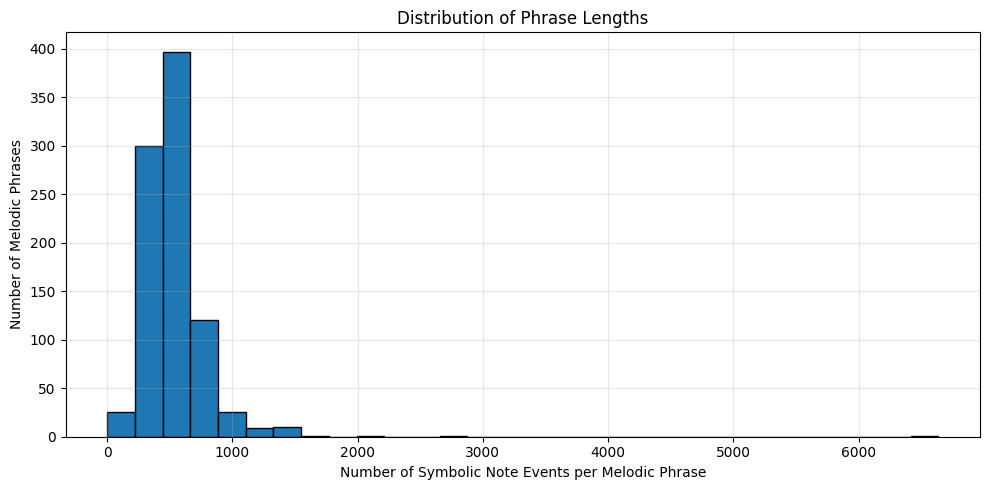

In [27]:
# =============================================================================
# Distribution of Phrase Lengths
# =============================================================================

plt.figure(figsize=(10, 5))

plt.hist(
    phrase_lengths,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Phrase Lengths")
plt.xlabel("Number of Symbolic Note Events per Melodic Phrase")
plt.ylabel("Number of Melodic Phrases")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation of the Distribution of Phrase Lengths

The distribution of phrase lengths indicates that melodic phrases in the Turkish Makam Melodic Phrase Dataset exhibit considerable structural diversity. While shorter phrases occur more frequently, the corpus also contains longer melodic phrases with substantially greater numbers of symbolic note events, reflecting variations in melodic development and phrase organization.

The observed distribution demonstrates that the dataset encompasses a broad range of phrase structures characteristic of Turkish makam music. This structural diversity provides a reliable foundation for phrase-level comparative analysis, melodic similarity analysis, symbolic sequence modeling, computational musicology, and machine learning applications.

### Symbolic Pitch Distribution (Koma53)

The Turkish Makam Melodic Phrase Dataset represents pitch using the traditional 53-comma (Koma53) tuning system employed in Turkish makam music. Examining the distribution of symbolic pitch values provides insight into the tonal characteristics of the corpus and reveals how frequently different pitch classes occur across annotated melodic phrases.

The following analyses summarize the frequency distribution of Koma53 pitch values and establish a statistical foundation for investigating melodic structure, pitch organization, and computational modeling of Turkish makam music.

In [28]:
# =============================================================================
# Symbolic pitch distribution (Koma53)
# =============================================================================

pitch_values = []
failed_files = []

for txt_file in annotation_root.rglob("*.txt"):

    try:

        with open(txt_file, "r", encoding="cp1254", errors="ignore") as f:

            header = f.readline().strip().split("\t")

            if "Koma53" not in header:
                continue

            pitch_index = header.index("Koma53")

            for line in f:

                line = line.strip()

                if not line:
                    continue

                fields = line.split("\t")

                if pitch_index < len(fields):

                    try:

                        value = float(fields[pitch_index])

                        pitch_values.append(value)

                    except ValueError:
                        continue

    except Exception as e:

        failed_files.append((txt_file.name, str(e)))

print(f"Successfully read : {len(list(annotation_root.rglob('*.txt')))}")
print(f"Failed to read    : {len(failed_files)}")

pitch_series = pd.Series(
    pitch_values,
    name="Koma53"
)

display(
    pitch_series
        .describe()
        .round(2)
        .to_frame()
)

Successfully read : 890
Failed to read    : 0


,Koma53
count,469530.00
mean,295.81
std,99.66
min,-1.00
25%,310.00
50%,327.00
75%,340.00
max,402.00


### Interpretation of the Symbolic Pitch Distribution

The symbolic pitch distribution reveals that pitch usage within the Turkish Makam Melodic Phrase Dataset is not uniformly distributed across the 53-comma (Koma53) pitch system. Instead, certain pitch values occur considerably more frequently than others, indicating that specific pitch classes are used more prominently throughout the melodic phrase corpus.

These findings reflect the characteristic tonal organization of Turkish makam music and demonstrate that the dataset captures meaningful pitch usage patterns suitable for computational analysis. Consequently, the symbolic pitch statistics provide a reliable quantitative foundation for investigating melodic structure, pitch organization, phrase similarity, symbolic pattern discovery, computational musicology, and machine learning applications based on symbolic music representations.

### Distribution of Symbolic Pitch Values

The following histogram illustrates the frequency distribution of symbolic pitch values represented in the 53-comma (Koma53) pitch system. Visualizing the distribution of pitch values provides insight into the tonal characteristics of the corpus, highlights the most frequently occurring pitch classes, and reveals the overall pitch usage patterns across annotated melodic phrases.

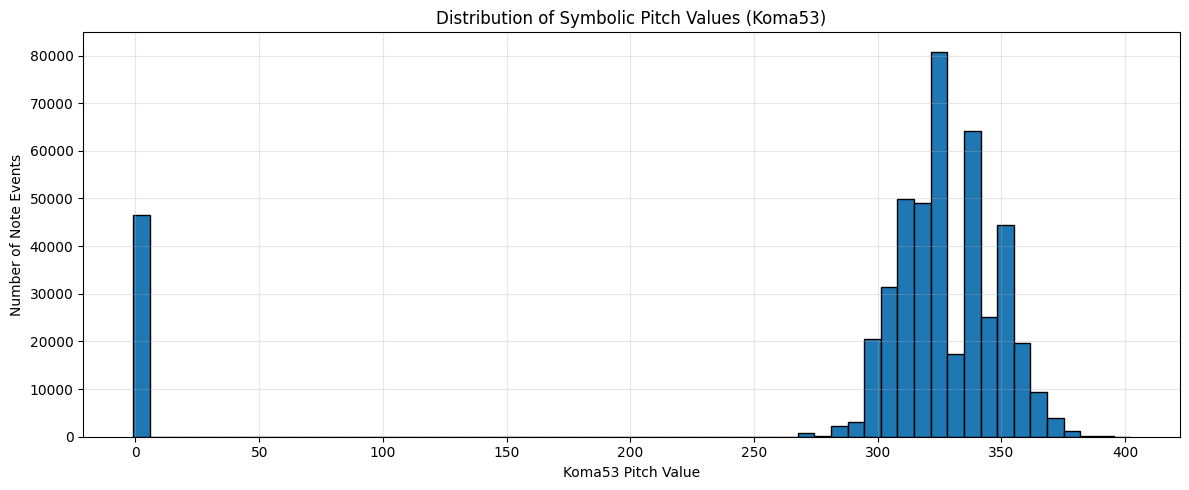

In [29]:
# =============================================================================
# Distribution of Symbolic Pitch Values
# =============================================================================

plt.figure(figsize=(12, 5))

plt.hist(
    pitch_series,
    bins=60,
    edgecolor="black"
)

plt.title("Distribution of Symbolic Pitch Values (Koma53)")
plt.xlabel("Koma53 Pitch Value")
plt.ylabel("Number of Note Events")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation of the Symbolic Pitch Distribution

The symbolic pitch distribution reveals that pitch usage within the Turkish Makam Melodic Phrase Dataset is not uniformly distributed across the 53-comma pitch system. Instead, certain pitch values occur considerably more frequently than others, reflecting the characteristic tonal organization and pitch preferences of Turkish makam music.

This distribution is consistent with the modal structure of Turkish makam music, in which specific pitch collections play a central role in melodic organization. Consequently, the pitch statistics provide a reliable quantitative foundation for investigating melodic structure, symbolic pattern discovery, phrase similarity analysis, clustering, and machine learning applications based on symbolic pitch representations.

### Duration Statistics

Each symbolic note event in the Turkish Makam Melodic Phrase Dataset is associated with a duration value expressed in milliseconds (`Ms`). Analyzing the distribution of note durations provides insight into the rhythmic characteristics of the corpus and reveals how temporal values are distributed across annotated melodic phrases.

The following statistics summarize the distribution of note durations extracted from all melodic phrase annotation files. These analyses establish a quantitative foundation for investigating rhythmic organization, temporal structure, melodic similarity, and computational modeling of Turkish makam music.

In [30]:
# =============================================================================
# Duration statistics
# =============================================================================

duration_values = []
failed_files = []

for txt_file in annotation_root.rglob("*.txt"):

    try:

        with open(txt_file, "r", encoding="cp1254", errors="ignore") as f:

            header = f.readline().strip().split("\t")

            if "Ms" not in header and "MS" not in header:
                continue

            duration_column = "Ms" if "Ms" in header else "MS"
            duration_index = header.index(duration_column)

            for line in f:

                line = line.strip()

                if not line:
                    continue

                fields = line.split("\t")

                if duration_index < len(fields):

                    try:
                        value = float(fields[duration_index])

                        duration_values.append(value)

                    except ValueError:
                        continue

    except Exception as e:

        failed_files.append((txt_file.name, str(e)))

print(f"Successfully read : {len(list(annotation_root.rglob('*.txt')))}")
print(f"Failed to read    : {len(failed_files)}")

duration_series = pd.Series(
    duration_values,
    name="Duration (ms)"
)

display(
    duration_series
        .describe()
        .round(2)
        .to_frame()
)

Successfully read : 890
Failed to read    : 0


,Duration (ms)
count,471122.00
mean,387.56
std,352.18
min,0.00
25%,208.00
50%,278.00
75%,455.00
max,6000.00


### Interpretation of the Duration Statistics

The duration statistics reveal substantial variability in the temporal characteristics of symbolic note events across the Turkish Makam Melodic Phrase Dataset. While shorter note durations occur more frequently, longer duration values are observed less often, indicating diversity in rhythmic organization and temporal structure among melodic phrases.

These findings demonstrate that the dataset captures a broad range of rhythmic patterns characteristic of Turkish makam music. Consequently, the duration statistics provide a reliable quantitative foundation for rhythm analysis, temporal pattern analysis, melodic similarity analysis, computational musicology, and machine learning applications based on symbolic music representations.

### Distribution of Note Durations

The following histogram illustrates the distribution of symbolic note durations expressed in milliseconds (`Ms`). Visualizing the duration distribution provides insight into the rhythmic characteristics of the corpus, identifies the most frequently occurring note durations, and reveals the temporal patterns underlying melodic phrase construction in Turkish makam music.

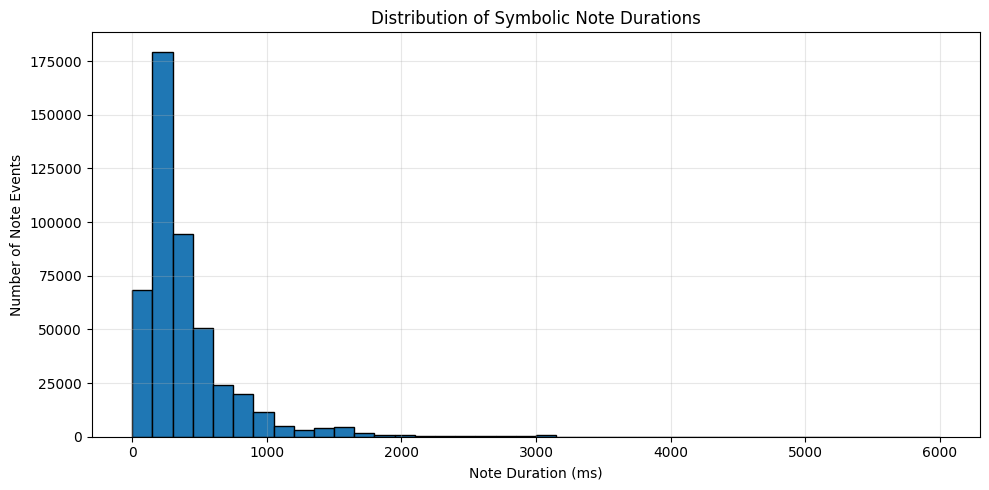

In [31]:
# =============================================================================
# Distribution of Note Durations
# =============================================================================

plt.figure(figsize=(10, 5))

plt.hist(
    duration_series,
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Symbolic Note Durations")
plt.xlabel("Note Duration (ms)")
plt.ylabel("Number of Note Events")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation of the Distribution of Note Durations

The distribution of symbolic note durations indicates that the Turkish Makam Melodic Phrase Dataset contains a wide range of temporal values. While shorter note durations occur more frequently throughout the corpus, longer durations appear less often, reflecting the diversity of rhythmic structures and temporal organization found in Turkish makam music.

The observed distribution demonstrates that the dataset captures a broad spectrum of rhythmic characteristics, ranging from rapidly articulated note sequences to more sustained melodic events. This temporal diversity provides a reliable foundation for rhythm analysis, melodic similarity analysis, symbolic sequence modeling, computational musicology, and machine learning applications based on symbolic music representations.

### Offset Statistics

The `Offset` attribute represents the temporal position of each symbolic note event within a melodic phrase. Analyzing the distribution of offset values provides insight into the temporal organization of melodic phrases by describing where note events occur throughout the phrase structure.

The following statistics summarize the distribution of offset values extracted from all melodic phrase annotation files. These analyses provide a quantitative foundation for investigating temporal progression, phrase organization, melodic similarity, and computational modeling of Turkish makam music.

In [32]:
# =============================================================================
# Offset statistics
# =============================================================================

offset_values = []
failed_files = []

for txt_file in annotation_root.rglob("*.txt"):

    try:

        with open(txt_file, "r", encoding="cp1254", errors="ignore") as f:

            header = f.readline().strip().split("\t")

            if "Offset" not in header:
                continue

            offset_index = header.index("Offset")

            for line in f:

                line = line.strip()

                if not line:
                    continue

                fields = line.split("\t")

                if offset_index < len(fields):

                    try:

                        value = float(fields[offset_index])

                        offset_values.append(value)

                    except ValueError:
                        continue

    except Exception as e:

        failed_files.append((txt_file.name, str(e)))

print(f"Successfully read : {len(list(annotation_root.rglob('*.txt')))}")
print(f"Failed to read    : {len(failed_files)}")

offset_series = pd.Series(
    offset_values,
    name="Offset"
)

display(
    offset_series
        .describe()
        .round(2)
        .to_frame()
)

Successfully read : 890
Failed to read    : 0


,Offset
count,416642.00
mean,33.69
std,33.11
min,0.00
25%,12.75
50%,26.11
75%,44.33
max,390.00


### Interpretation of the Offset Statistics

The offset statistics reveal substantial variability in the temporal positions of symbolic note events within melodic phrases. Note events occur at different positions throughout the phrase structure, reflecting the temporal progression and sequential organization of melodic phrases across the corpus.

These findings demonstrate that the Turkish Makam Melodic Phrase Dataset captures diverse temporal structures that are characteristic of symbolic Turkish makam music. Consequently, the offset statistics provide a reliable quantitative foundation for phrase alignment, temporal pattern analysis, melodic similarity analysis, symbolic sequence modeling, computational musicology, and machine learning applications based on symbolic music representations.

### Distribution of Offset Values

The following histogram illustrates the distribution of offset values representing the temporal positions of symbolic note events within melodic phrases. Visualizing the distribution of offset values provides insight into how note events are organized throughout melodic phrases, identifies commonly occurring temporal positions, and reveals the overall temporal organization of the Turkish Makam Melodic Phrase Dataset.

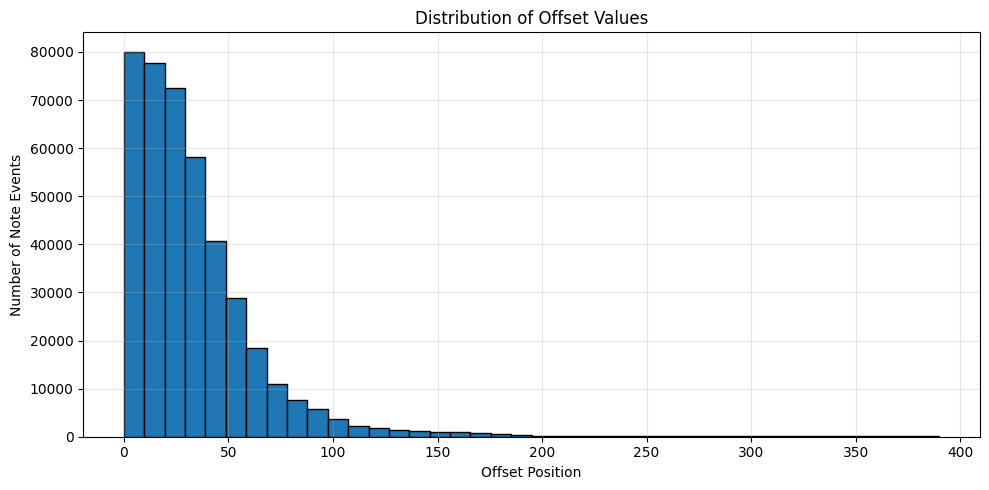

In [34]:
# =============================================================================
# Distribution of Offset Values
# =============================================================================

plt.figure(figsize=(10, 5))

plt.hist(
    offset_series,
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Offset Values")
plt.xlabel("Offset Position")
plt.ylabel("Number of Note Events")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation of the Distribution of Offset Values

The distribution of offset values indicates that symbolic note events occur throughout different temporal positions within melodic phrases rather than being concentrated at a single location. This variability reflects the temporal progression and structural organization of melodic phrases across the corpus.

The observed distribution demonstrates that the dataset captures diverse temporal patterns characteristic of Turkish makam music. These temporal characteristics provide a reliable quantitative foundation for phrase alignment, temporal pattern analysis, melodic similarity analysis, symbolic sequence modeling, computational musicology, and machine learning applications based on symbolic music representations.

### Key Findings

The statistical analyses demonstrate that the Turkish Makam Melodic Phrase Dataset provides a comprehensive and well-structured phrase-level representation of Turkish makam music. The analyses characterized the structural variability of melodic phrases, quantified symbolic pitch usage within the 53-comma pitch system, examined note duration distributions, and described the temporal organization of note events through offset analysis.

Together, these findings establish a reliable statistical foundation for phrase-level symbolic music analysis, melodic similarity analysis, symbolic sequence modeling, computational musicology, and machine learning applications based on symbolic music representations.

## Comparative Summary

The statistical analyses presented throughout this notebook demonstrate that the three Turkish makam music datasets represent complementary levels of symbolic musical abstraction and therefore require different analytical approaches.

**SymbTr v3.0** provides feature-based numerical representations that support descriptive statistics, feature variability analysis, missing value analysis, correlation analysis, and machine learning. The **Turkish Makam Symbolic Phrase Segmentation Dataset** focuses on expert-generated phrase boundary annotations, enabling analyses of corpus organization, annotation coverage, expert contributions, and symbolic note event distributions. In contrast, the **Turkish Makam Melodic Phrase Dataset** represents melodic phrases as symbolic note sequences, supporting phrase-level analyses of phrase length, symbolic pitch usage within the 53-comma (Koma53) pitch system, note duration distributions, and temporal organization through offset analysis.

Together, these complementary analyses provide quantitative insight into the structural and musical characteristics of Turkish makam music while demonstrating that different symbolic music representations require analysis strategies tailored to their underlying data structures. The unified computational workflow presented in this notebook establishes a reproducible statistical foundation for subsequent visualization, dimensionality reduction, clustering, similarity analysis, and machine learning throughout the Turkish Delight Corpus (TDC) tutorial.

| Dataset                                                | Representation                        | Primary Analysis Unit  | Statistical Analyses Performed                                                                               | Typical Applications                                                                                  |
| ------------------------------------------------------ | ------------------------------------- | ---------------------- | ------------------------------------------------------------------------------------------------------------ | ----------------------------------------------------------------------------------------------------- |
| **SymbTr v3.0**                                        | Numerical feature vectors             | Complete musical score | Descriptive statistics, missing value analysis, feature variability, correlation analysis                    | Statistical analysis, PCA, clustering, similarity analysis, machine learning                          |
| **Turkish Makam Symbolic Phrase Segmentation Dataset** | Expert-generated symbolic annotations | Complete musical score | Corpus overview, expert annotation statistics, note event statistics                                         | Phrase segmentation, annotation analysis, computational musicology, expert agreement analysis         |
| **Turkish Makam Melodic Phrase Dataset**               | Symbolic note sequences               | Melodic phrase         | Corpus overview, phrase length statistics, Koma53 pitch distribution, duration statistics, offset statistics | Melodic analysis, symbolic music processing, sequence modeling, similarity analysis, machine learning |

